In [12]:
# Connect this notebook to our shared folder to access/read the Kaggle data directly
from google.colab import drive
drive.mount('/content/drive')

# Load training data file to notebook
import pandas as pd

file_path = '/content/drive/MyDrive/BTT_continuumx/WiDSWorldWide_GlobalDathon26/train.csv'

# Read train data and store in dataframe
df = pd.read_csv(file_path)

# Verify - display first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


### Info about the columns

1. The Identifiers & Timing (When & Where)
    - event_id, event_start_hour, event_start_dayofweek, event_start_month

2. The Fire's Behavior (The 5-Hour Window)
    - area_first_ha, area_growth_abs_0_5h, area_growth_rate_ha_per_h, log1p_area_first
    - "ha" = hectares
    - The dataset is showing you how big the fire was initially, and exactly how fast it grew during those critical first 5 hours.

3. The Spatial Metrics (Direction & Speed)
    - alignment_cos, cross_track_component, along_track_speed
    - This describes how the fire is moving across the terrain. Is it being pushed rapidly in one direction by the wind, or spreading out evenly?

4. The Target Variable (The Answer Key)
    - time_to_hit_hours (most important column => the "target" / need to predict this)

In [13]:
print(df.columns)

Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_hit_hours', 'event'],
      dtype='object')


## Data Cleaning and Preprocessing:

In [14]:
# 1) Remove duplicates

before = len(df)
df = df.drop_duplicates()
print("Duplicates removed:", before - len(df))

# 2) Filter invalid / anomalous rows
# (minimum safe checks based on your target column)

if "time_to_hit_hours" not in df.columns:
    raise ValueError("Column 'time_to_hit_hours' not found in train.csv")

# Remove rows where time_to_hit_hours is missing (can't create targets)
df = df.dropna(subset=["time_to_hit_hours"])

# Remove negative time_to_hit_hours (invalid)
df = df[df["time_to_hit_hours"] >= 0]

print("Shape after invalid filtering:", df.shape)

# 3) Handle missing values
# - numeric: mean
# - categorical/text: mode

import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill numeric NaNs with column mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical NaNs with most frequent value (mode)
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

print("Total missing values after filling:", int(df.isna().sum().sum()))

# 4) Convert text categories into numbers (one-hot encoding)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)

# 5) Create 4 brand-new target columns from time_to_hit_hours

df_encoded["Target_12h"] = (df_encoded["time_to_hit_hours"] <= 12).astype(int)
df_encoded["Target_24h"] = (df_encoded["time_to_hit_hours"] <= 24).astype(int)
df_encoded["Target_48h"] = (df_encoded["time_to_hit_hours"] <= 48).astype(int)
df_encoded["Target_72h"] = (df_encoded["time_to_hit_hours"] <= 72).astype(int)

display(df_encoded[["time_to_hit_hours", "Target_12h", "Target_24h", "Target_48h", "Target_72h"]].head(10))

Duplicates removed: 0
Shape after invalid filtering: (221, 37)
Total missing values after filling: 0
Shape after one-hot encoding: (221, 37)


,time_to_hit_hours,Target_12h,Target_24h,Target_48h,Target_72h
0,18.892512,0,1,1,1
1,22.048108,0,1,1,1
2,0.888895,1,1,1,1
3,60.953021,0,0,0,1
4,44.990274,0,0,1,1
5,44.026384,0,0,1,1
6,14.845392,0,1,1,1
7,66.767927,0,0,0,1
8,39.912630,0,0,1,1
9,54.638109,0,0,0,1


## EDA:

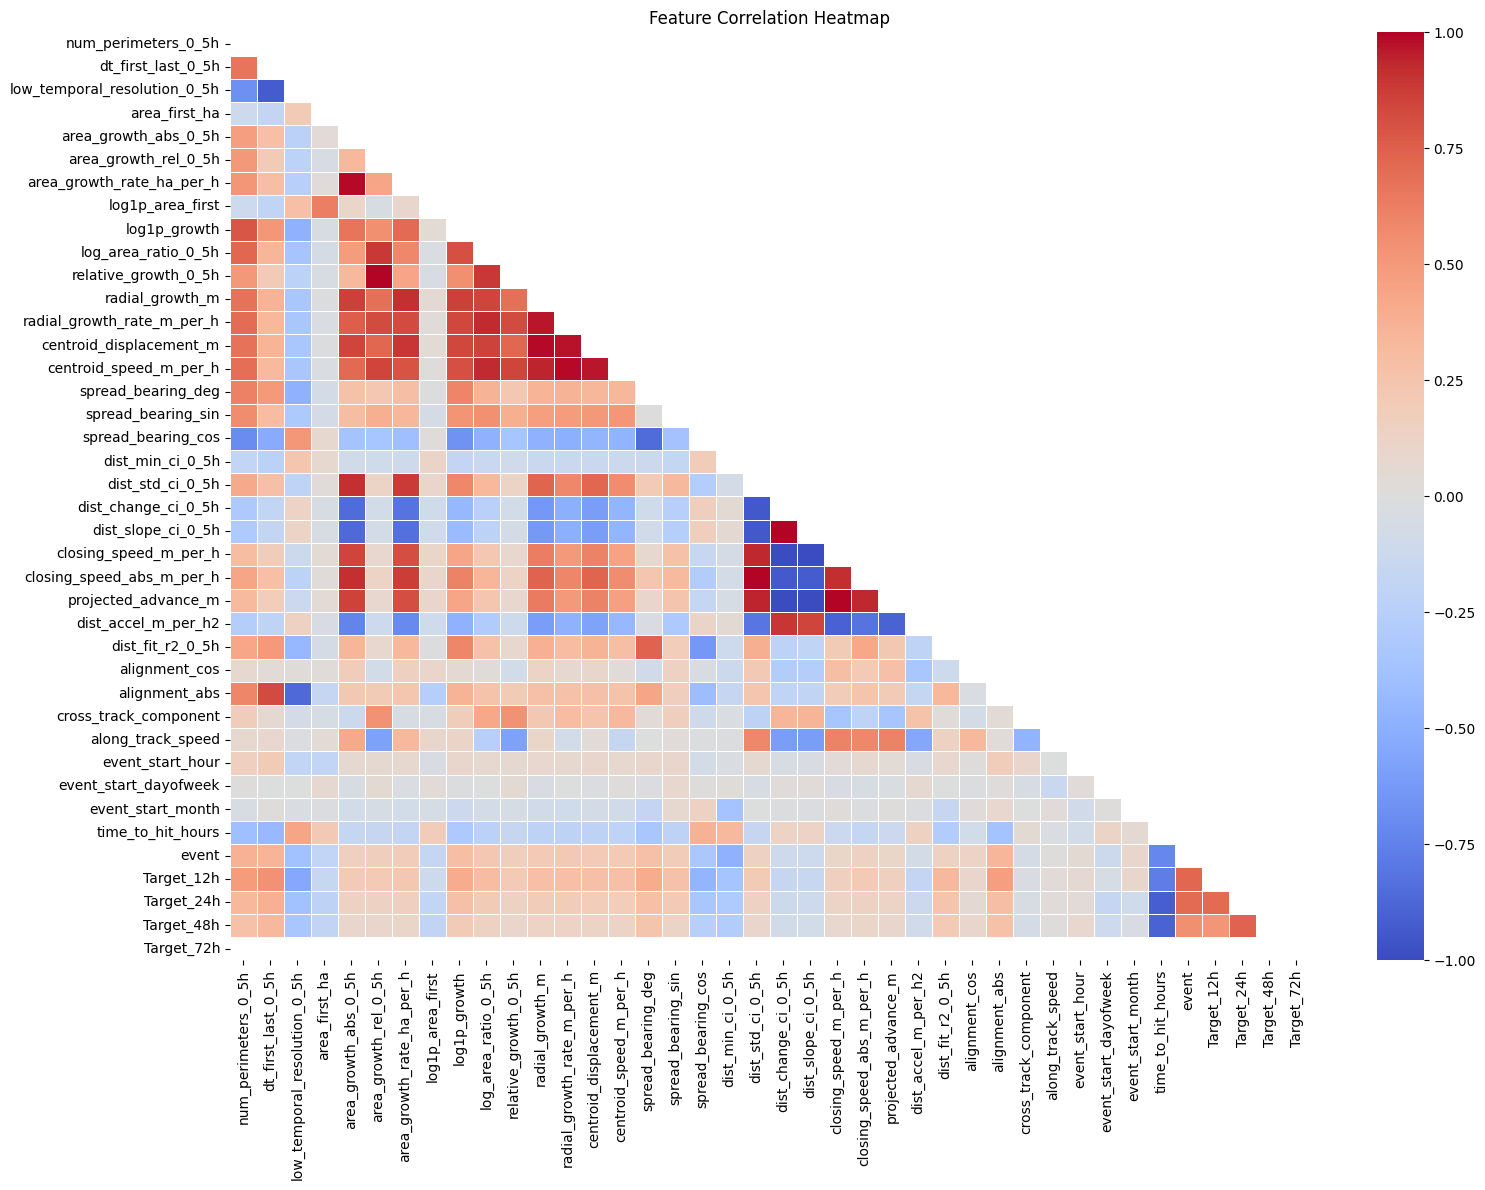

Top 15 features correlated with event:
time_to_hit_hours              -0.719485
dist_min_ci_0_5h               -0.481379
low_temporal_resolution_0_5h   -0.379117
num_perimeters_0_5h             0.370501
dt_first_last_0_5h              0.352954
alignment_abs                   0.349115
spread_bearing_cos             -0.323189
log1p_growth                    0.292688
spread_bearing_deg              0.281012
log_area_ratio_0_5h             0.229327
radial_growth_rate_m_per_h      0.214956
radial_growth_m                 0.209343
centroid_speed_m_per_h          0.209254
centroid_displacement_m         0.207992
spread_bearing_sin              0.188252
Name: event, dtype: float64


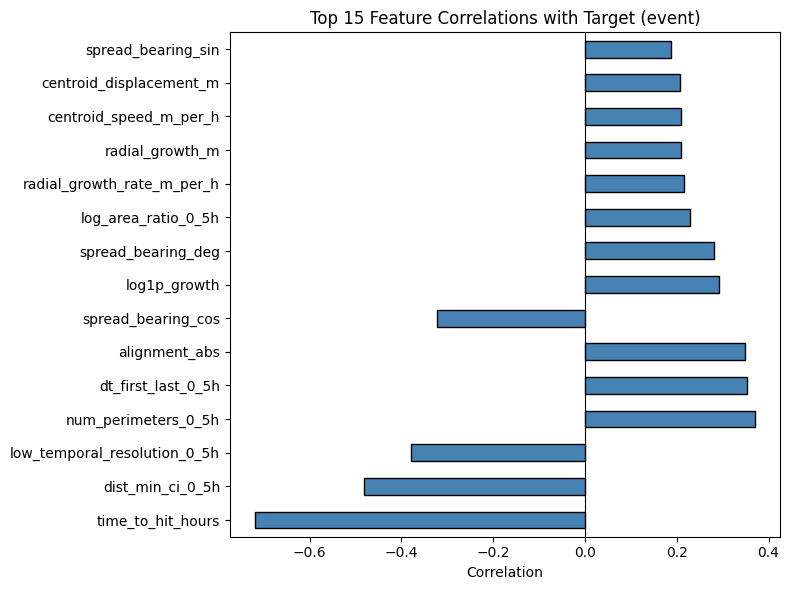

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# This is a heatmap showing how related every column is to every other column
# Correlation goes from -1 to 1: 1 = move together, 0 = no relationship, -1 = move opposite
plt.figure(figsize=(16, 12))

# This calculates the correlations (we drop event_id since it's just an ID, not useful)
corr = df_encoded.drop(columns=['event_id']).corr()

# This hides the upper triangle since it's just a mirror of the lower half
mask = np.triu(np.ones_like(corr, dtype=bool))

# This draws the heatmap -- red = positive correlation, blue = negative
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# This finds which features are most correlated with our target (event)
# These are the columns most useful for predicting whether an event happens

# This pulls just the correlations with 'event' and sorts by strongest relationship
target_corr = df.drop(columns=['event_id']).corr()['event'].drop('event').sort_values(key=abs, ascending=False)

print('Top 15 features correlated with event:')
print(target_corr.head(15))

# This is a horizontal bar chart (easier to read long feature names)
target_corr.head(15).plot(kind='barh', figsize=(8, 6), color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Correlations with Target (event)')
plt.xlabel('Correlation')

# This draws a line at 0 so we can see positive vs negative correlations clearly
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Feature Engineering

In [16]:
# This is a copy of the original dataframe so we don't mess up the original
df_eng = df_encoded.copy()

# This is a combined "how intensely is this fire spreading" score
# If both radial growth and area growth are high, the fire is growing fast in all directions
df_eng['spread_intensity'] = df_eng['radial_growth_rate_m_per_h'] * df_eng['area_growth_rate_ha_per_h']

# This is a fire momentum score -- how fast the center moves × how fast the area grows
# A fire doing both at once is way more dangerous than one doing just one
df_eng['fire_momentum'] = df_eng['centroid_speed_m_per_h'] * df_eng['area_growth_rate_ha_per_h']

# This is how much pressure the fire is putting on containment lines
# We flip the sign so higher = more pressure, and divide by distance so close fires score higher
# The +1 just prevents dividing by zero
df_eng['containment_pressure'] = -df_eng['dist_change_ci_0_5h'] / (df_eng['dist_min_ci_0_5h'] + 1)

# This is an urgency score -- even a slow fire is urgent if it's already very close to containment
df_eng['urgency_score'] = df_eng['closing_speed_abs_m_per_h'] / (df_eng['dist_min_ci_0_5h'] + 1)

# This is a log-scaled version of fire area so huge outliers don't dominate the model
# log1p means log(1 + x) which handles 0 values safely
df_eng['fire_size_log'] = np.log1p(df_eng['area_first_ha'])

# This combines how aligned the fire spread is with its growth rate
# A perfectly aligned AND fast-growing fire is especially dangerous
df_eng['alignment_spread_product'] = df_eng['alignment_abs'] * df_eng['radial_growth_rate_m_per_h']

# This is 1 if the fire started in the afternoon (12pm-6pm), 0 if not
# Fires are most active in the afternoon due to heat and low humidity
# .between() gives True/False and .astype(int) turns that into 1/0
df_eng['is_afternoon'] = df_eng['event_start_hour'].between(12, 18).astype(int)

# This is 1 if the fire started in peak fire season (June-September), 0 if not
df_eng['is_peak_season'] = df_eng['event_start_month'].between(6, 9).astype(int)

# This is 1 if the fire started on a weekend, 0 if not
# In pandas, 5 = Saturday and 6 = Sunday
df_eng['is_weekend'] = df_eng['event_start_dayofweek'].isin([5, 6]).astype(int)

# This is a combined time risk score -- 0 = low risk time, 2 = highest risk time
df_eng['time_risk'] = df_eng['is_afternoon'] + df_eng['is_peak_season']

# This is 1 if the fire is speeding up toward containment lines, 0 if not
# Negative dist_accel means the fire is accelerating closer (bad!)
df_eng['accelerating_toward_containment'] = (df_eng['dist_accel_m_per_h2'] < 0).astype(int)

# This is the distance to containment normalized by fire size
# A huge fire that's far from containment is more worrying than a tiny one at the same distance
df_eng['containment_dist_normalized'] = df_eng['dist_min_ci_0_5h'] / (df_eng['area_first_ha'] + 1)

# This is a log-smoothed version of time_to_hit so the model can learn from it more easily
df_eng['log_time_to_hit'] = np.log1p(df_eng['time_to_hit_hours'])

# This prints a summary of all the new columns we added
print('New features:', [c for c in df_eng.columns if c not in df.columns])
print('New shape:', df_eng.shape)

New features: ['Target_12h', 'Target_24h', 'Target_48h', 'Target_72h', 'spread_intensity', 'fire_momentum', 'containment_pressure', 'urgency_score', 'fire_size_log', 'alignment_spread_product', 'is_afternoon', 'is_peak_season', 'is_weekend', 'time_risk', 'accelerating_toward_containment', 'containment_dist_normalized', 'log_time_to_hit']
New shape: (221, 54)


### Feature correlation after feature engineering

log_time_to_hit                   -0.744649
accelerating_toward_containment    0.299165
alignment_spread_product           0.204245
urgency_score                      0.168261
fire_size_log                     -0.167912
spread_intensity                   0.151306
fire_momentum                      0.148329
containment_dist_normalized       -0.139257
time_risk                          0.138969
is_weekend                        -0.119654
containment_pressure               0.112221
is_afternoon                       0.103226
is_peak_season                     0.085670
Name: event, dtype: float64


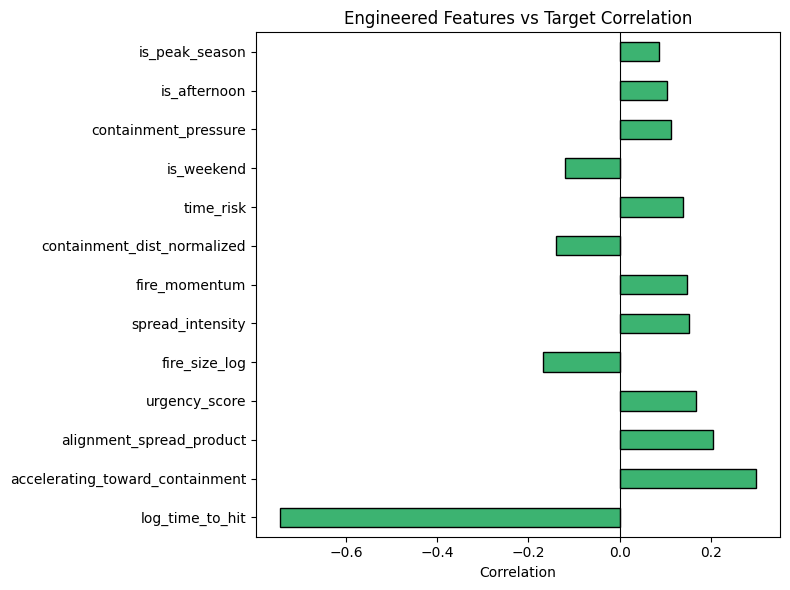

In [17]:
# This checks how well our new features correlate with the target
# Good correlation means they'll probably help the model!
new_cols = [c for c in df_eng.columns if c not in df_encoded.columns]

# This pulls the correlations between new features and 'event' and sorts by strongest
eng_corr = df_eng[new_cols + ['event']].corr()['event'].drop('event').sort_values(key=abs, ascending=False)
print(eng_corr)

eng_corr.plot(kind='barh', figsize=(8, 6), color='mediumseagreen', edgecolor='black')
plt.title('Engineered Features vs Target Correlation')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Model Building: XGBoost Algorithm

In [18]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Define 4 targets to predict
targets = ['Target_12h', 'Target_24h', 'Target_48h', 'Target_72h']

# Define features (X)
# Drop the 4 target columns, ID, and original time column (prevent data leakage)
X = df_encoded.drop(columns=[
    'Target_12h', 'Target_24h', 'Target_48h', 'Target_72h',
    'time_to_hit_hours', 'event_id'
])

# Create dictionaries to store trained models and scores
trained_models = {}
auc_scores = {}

# Loop through each target --> train model --> score it
for target in targets:
    # Isolate target variable (y)
    y = df_encoded[target]

    # Check if target column only has one unique value (ie. all 1s)
    unique_classes = y.unique()
    if len(unique_classes) == 1:
        only_value = unique_classes[0]
        print(f"{target} only contains the value {only_value}")
        # Skip XGBoost --> will hardcode predictions to the value for this target

        # Save string note instead
        trained_models[target] = f"Always_{only_value}"
        continue

    # If there are both 0s and 1s:
    # Split --> 80% training and 20% validation
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        # n_estimators=100,      # number of decision trees
        # learning_rate=0.1,     # how aggressively it corrects mistakes
        # max_depth=5,           # how deep each tree can get
        # random_state=42,       # ensures same results every run
        # eval_metric='logloss'  # evaluation metric (standard for binary classification)
        n_estimators=500,  # More trees
        learning_rate=0.03, # Slower learning rate
        max_depth=6, # Slightly deeper trees
        subsample=0.8, # Prevent overfitting by using 80% of rows per tree
        colsample_bytree=0.8, # Prevent overfitting by using 80% of columns per tree
        eval_metric='auc', # Optimize directly for AUC instead of logloss
        random_state=42
    )

    # Train the model on the 80% training data
    model.fit(X_train, y_train)

    # Make probability predictions on the 20% validation data
    # predict_proba() outputs two columns:
    # [Probability of 0 (fire not hitting), Probability of 1 (fire hitting)]
    # Only want the second column
    predictions = model.predict_proba(X_valid)[:, 1]

    # Evaluate model using AUC (Area Under the Curve) --> standard probability metric
    try:
        auc = roc_auc_score(y_valid, predictions)
        print(f"Validation AUC for {target}: {auc:.4f}\n")
        auc_scores[target] = auc
    except ValueError:
        # Catches an error if the validation set accidentally only contains 1s or 0s
        print(f"**Could not calculate AUC for {target}.\n")

    # Save trained model into dictionary --> use later on test data
    trained_models[target] = model

# Calculate overall average score
if auc_scores:
    average_auc = sum(auc_scores.values()) / len(auc_scores)
    print(f"\n*** Average Baseline AUC Score: {average_auc:.4f}")

Validation AUC for Target_12h: 0.9495

Validation AUC for Target_24h: 0.8696

Validation AUC for Target_48h: 0.8487

Target_72h only contains the value 1

*** Average Baseline AUC Score: 0.8893


## Run test.csv and export dataset in correct submission format

In [19]:
import pandas as pd
import numpy as np

# ==========================================
# Testing on test.csv
# ==========================================

# 1. Load the un-graded Test Data
test_path = '/content/drive/MyDrive/BTT_continuumx/WiDSWorldWide_GlobalDathon26/test.csv'
test_df = pd.read_csv(test_path)

# 2. VAISH'S CLEANING
# Fill missing numeric values with the mean, and categorical with the mode
num_cols = test_df.select_dtypes(include=[np.number]).columns
cat_cols = test_df.select_dtypes(exclude=[np.number]).columns

test_df[num_cols] = test_df[num_cols].fillna(test_df[num_cols].mean())
for col in cat_cols:
    if test_df[col].isna().any():
        test_df[col] = test_df[col].fillna(test_df[col].mode(dropna=True)[0])

# One-hot encode text categories
test_encoded = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

# 3. FANIZZA'S FEATURE ENGINEERING
# We must apply the exact same math to the test data so the columns match!
test_encoded['spread_intensity'] = test_encoded['radial_growth_rate_m_per_h'] * test_encoded['area_growth_rate_ha_per_h']
test_encoded['fire_momentum'] = test_encoded['centroid_speed_m_per_h'] * test_encoded['area_growth_rate_ha_per_h']
test_encoded['containment_pressure'] = -test_encoded['dist_change_ci_0_5h'] / (test_encoded['dist_min_ci_0_5h'] + 1)
test_encoded['urgency_score'] = test_encoded['closing_speed_abs_m_per_h'] / (test_encoded['dist_min_ci_0_5h'] + 1)
test_encoded['fire_size_log'] = np.log1p(test_encoded['area_first_ha'])
test_encoded['alignment_spread_product'] = test_encoded['alignment_abs'] * test_encoded['radial_growth_rate_m_per_h']
test_encoded['is_afternoon'] = test_encoded['event_start_hour'].between(12, 18).astype(int)
test_encoded['is_peak_season'] = test_encoded['event_start_month'].between(6, 9).astype(int)
test_encoded['is_weekend'] = test_encoded['event_start_dayofweek'].isin([5, 6]).astype(int)
test_encoded['time_risk'] = test_encoded['is_afternoon'] + test_encoded['is_peak_season']
test_encoded['accelerating_toward_containment'] = (test_encoded['dist_accel_m_per_h2'] < 0).astype(int)
test_encoded['containment_dist_normalized'] = test_encoded['dist_min_ci_0_5h'] / (test_encoded['area_first_ha'] + 1)
# Notice: We intentionally do NOT create 'log_time_to_hit' to avoid the data leak error!

# 4. COLUMN ALIGNMENT
# If a column existed in training but not in testing, add it as 0s
missing_cols = set(X.columns) - set(test_encoded.columns)
for c in missing_cols:
    test_encoded[c] = 0

# Reorder the test columns to perfectly match the training features (X)
X_test = test_encoded[X.columns]

# Save the event_ids for the final submission file
test_ids = test_df['event_id']

# 5. GENERATE PREDICTIONS!
target_mapping = {
    'Target_12h': 'prob_12h',
    'Target_24h': 'prob_24h',
    'Target_48h': 'prob_48h',
    'Target_72h': 'prob_72h'
}

predictions = {}

for train_target, sub_col in target_mapping.items():
    model = trained_models[train_target]

    # Check if this target was the one we hardcoded (Target_72h)
    if isinstance(model, str) and model.startswith("Always_"):
        hardcoded_val = float(model.split("_")[1])
        predictions[sub_col] = [hardcoded_val] * len(X_test)
        print(f"Filled {sub_col} with hardcoded value: {hardcoded_val}")
    else:
        # Ask the trained XGBoost model to predict the probability
        preds = model.predict_proba(X_test)[:, 1]
        predictions[sub_col] = preds
        print(f"Generated XGBoost predictions for {sub_col}")

# 6. EXPORT TO KAGGLE FORMAT
final_submission = pd.DataFrame({
    'event_id': test_ids,
    'prob_12h': predictions['prob_12h'],
    'prob_24h': predictions['prob_24h'],
    'prob_48h': predictions['prob_48h'],
    'prob_72h': predictions['prob_72h']
})

save_path = '/content/drive/MyDrive/BTT_continuumx/WiDSWorldWide_GlobalDathon26/baseline_submission3.csv'
final_submission.to_csv(save_path, index=False)

print("\n✅ Baseline submission successfully saved to Drive!")
display(final_submission.head())

Generated XGBoost predictions for prob_12h
Generated XGBoost predictions for prob_24h
Generated XGBoost predictions for prob_48h
Filled prob_72h with hardcoded value: 1.0

✅ Baseline submission successfully saved to Drive!


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.007403,0.052583,0.178474,1.0
1,13353600,0.123102,0.947609,0.991188,1.0
2,13942327,0.002925,0.009667,0.378469,1.0
3,16112781,0.822528,0.970346,0.959374,1.0
4,17132808,0.024783,0.082032,0.884103,1.0
